In [21]:
import numpy as np  
# Library for numerical operations (arrays, matrices, mathematical functions)

import pandas as pd  
# Used for data manipulation and analysis (DataFrames, CSV handling)

import seaborn as sns  
# Data visualization library for statistical plots

import matplotlib.pyplot as plt  
# Library for creating graphs and plots


df = pd.read_csv("Mall_Customers.csv")  
# Loads the dataset from a CSV file into a Pandas DataFrame

df.head()  
# Displays the first 5 rows of the dataset for quick inspection

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [23]:
df.shape
 # Will show the number of rows and columns (i.e,shape)

(200, 5)

In [24]:
df.info()  
# Provides summary of dataset: column names, data types, non-null values, memory usage


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [25]:

# Extracting specific features (columns) for clustering
X = df.iloc[:, [3, 4]].values  
# Selects 4th and 5th columns (Annual Income and Spending Score) and converts them into a NumPy array

X  
# Displays the extracted feature values

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

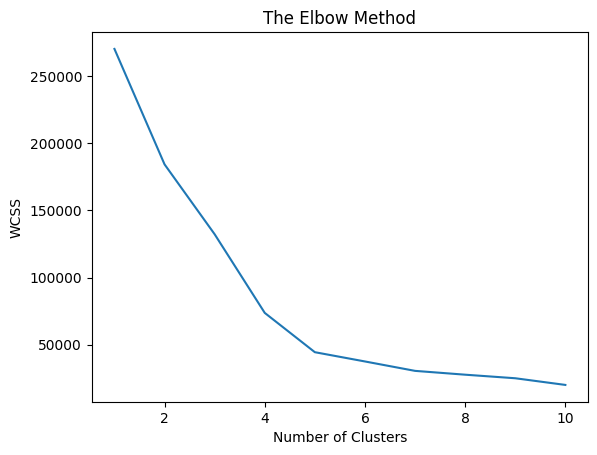

In [26]:
# Applying Elbow Method to find optimal number of clusters
from sklearn.cluster import KMeans  

wcss = []  
# List to store Within-Cluster Sum of Squares (WCSS) for different cluster counts

for i in range(1, 11):  
    # Loop runs from 1 to 10 to test different numbers of clusters

    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=5)  
    # Creates KMeans model with:
    # n_clusters = i → number of clusters
    # init = 'k-means++' → smart initialization for faster convergence
    # random_state = 5 → ensures reproducibility of results

    kmeans.fit(X)  
    # Fits the model to the data (computes cluster centers)

    wcss.append(kmeans.inertia_)  
    # inertia_ gives WCSS (sum of squared distances of points to nearest centroid)
    # Stored for plotting Elbow graph


# Plotting the Elbow Graph
plt.plot(range(1, 11), wcss)  
# Plots number of clusters vs WCSS

plt.title('The Elbow Method')  
# Title of the graph

plt.xlabel('Number of Clusters')  
# X-axis label

plt.ylabel('WCSS')  
# Y-axis label (measure of cluster compactness)

plt.show()  
# Displays the graph

In [27]:

# Training final KMeans model with optimal clusters (k = 5)
kmeansmodel = KMeans(n_clusters=5, init='k-means++', random_state=5)  
# Creates final clustering model with 5 clusters

y_kmeans = kmeansmodel.fit_predict(X)  
# Fits the model and assigns each data point to a cluster (returns cluster labels)

print(y_kmeans)  
# Prints cluster index (0 to 4) for each data point

[0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0
 4 0 4 0 4 0 1 0 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 3 2 3 1 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 1 3 2 3 2 3
 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3]


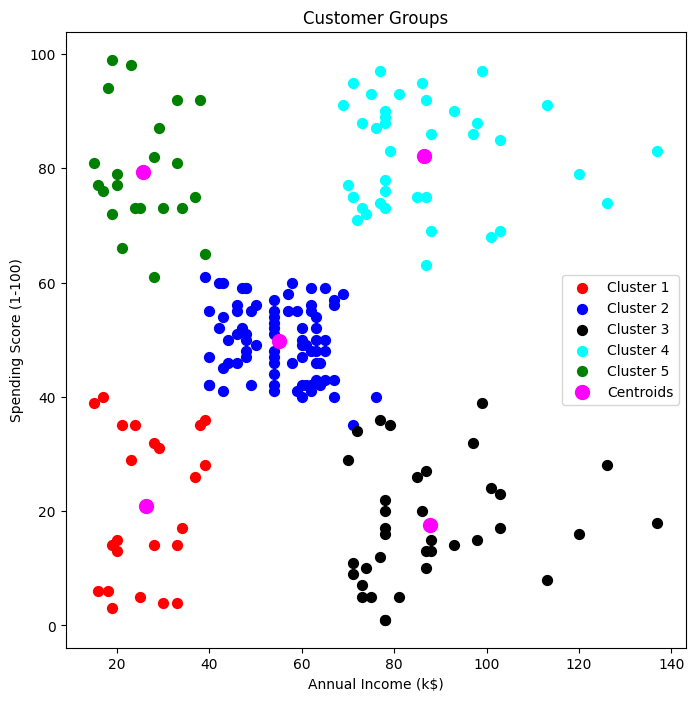

In [28]:

plt.figure(figsize=(8, 8))  
# Sets the size of the plot


# Plotting each cluster with different colors
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=50, c='red', label='Cluster 1')  
# Plots all points belonging to cluster 0

plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=50, c='blue', label='Cluster 2')  
# Plots all points belonging to cluster 1

plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=50, c='black', label='Cluster 3')  
# Plots all points belonging to cluster 2

plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=50, c='cyan', label='Cluster 4')  
# Plots all points belonging to cluster 3

plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=50, c='green', label='Cluster 5')  
# Plots all points belonging to cluster 4


# Plotting the centroids of clusters
plt.scatter(kmeansmodel.cluster_centers_[:, 0],
            kmeansmodel.cluster_centers_[:, 1],
            s=100, c='magenta', label='Centroids')  
# Plots the center point (mean position) of each cluster


plt.title('Customer Groups')  
# Title of the final cluster plot

plt.xlabel('Annual Income (k$)')  
# Label for X-axis

plt.ylabel('Spending Score (1-100)')  
# Label for Y-axis

plt.legend()  
# Displays legend to identify clusters

plt.show()  
# Displays the final clustered visualization